In [55]:
# ── Manipulación de datos ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Preprocesamiento / métricas ────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ── Utilidades ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

print('Todas las librerías cargadas correctamente')


Todas las librerías cargadas correctamente


In [56]:
df = pd.read_csv("sales_data.csv")
df.head(3)

,Order ID,Order Date,Ship Mode,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,US-2015-108966,10/11/2015,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


In [57]:
df.shape

(2121, 16)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       2121 non-null   str    
 1   Order Date     2121 non-null   str    
 2   Ship Mode      2121 non-null   str    
 3   Customer Name  2121 non-null   str    
 4   Segment        2121 non-null   str    
 5   Country        2121 non-null   str    
 6   City           2121 non-null   str    
 7   Region         2121 non-null   str    
 8   Product ID     2121 non-null   str    
 9   Category       2121 non-null   str    
 10  Sub-Category   2121 non-null   str    
 11  Product Name   2121 non-null   str    
 12  Sales          2121 non-null   float64
 13  Quantity       2121 non-null   int64  
 14  Discount       2121 non-null   float64
 15  Profit         2121 non-null   float64
dtypes: float64(3), int64(1), str(12)
memory usage: 265.3 KB


In [59]:
df.describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


In [60]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       2121 non-null   str           
 1   Order Date     2121 non-null   datetime64[us]
 2   Ship Mode      2121 non-null   str           
 3   Customer Name  2121 non-null   str           
 4   Segment        2121 non-null   str           
 5   Country        2121 non-null   str           
 6   City           2121 non-null   str           
 7   Region         2121 non-null   str           
 8   Product ID     2121 non-null   str           
 9   Category       2121 non-null   str           
 10  Sub-Category   2121 non-null   str           
 11  Product Name   2121 non-null   str           
 12  Sales          2121 non-null   float64       
 13  Quantity       2121 non-null   int64         
 14  Discount       2121 non-null   float64       
 15  Profit         2121 non-null   f

In [61]:
import warnings
warnings.filterwarnings('ignore')

In [62]:
#Ventas por mes
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))['Sales'].sum().reset_index() #Con reset index, order date pasa a ser una columna normal

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,6242.525
1,2014-02-28,1839.658
2,2014-03-31,14573.956
3,2014-04-30,7944.837
4,2014-05-31,6912.787


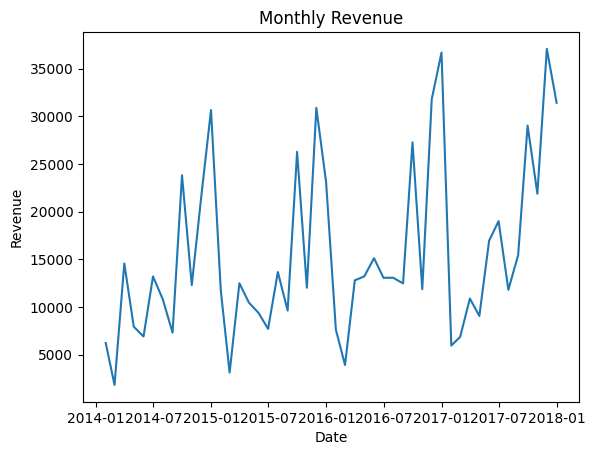

In [63]:
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title('Monthly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

In [64]:
# Date features
monthly_sales['year']    = monthly_sales['Order Date'].dt.year
monthly_sales['month']   = monthly_sales['Order Date'].dt.month
monthly_sales['quarter'] = monthly_sales['Order Date'].dt.quarter

# Lags
monthly_sales['lag_1']  = monthly_sales['Sales'].shift(1)
monthly_sales['lag_2']  = monthly_sales['Sales'].shift(2)
monthly_sales['lag_3']  = monthly_sales['Sales'].shift(3)
monthly_sales['lag_6']  = monthly_sales['Sales'].shift(6)
monthly_sales['lag_9']  = monthly_sales['Sales'].shift(9)
monthly_sales['lag_12'] = monthly_sales['Sales'].shift(12)

# Rolling features
monthly_sales['rolling_mean_3']  = monthly_sales['Sales'].shift(1).rolling(3).mean()
monthly_sales['rolling_std_3']   = monthly_sales['Sales'].shift(1).rolling(3).std()
monthly_sales['rolling_mean_6']  = monthly_sales['Sales'].shift(1).rolling(6).mean()
monthly_sales['rolling_mean_12'] = monthly_sales['Sales'].shift(1).rolling(12).mean()

# YoY growth y expanding mean
monthly_sales['yoy_growth']    = monthly_sales['Sales'].shift(12).pct_change(12)
monthly_sales['expanding_mean'] = monthly_sales['Sales'].shift(1).expanding().mean()

# Un solo dropna al final
monthly_sales.dropna(inplace=True)
monthly_sales.reset_index(drop=True, inplace=True)

print(monthly_sales.shape)
monthly_sales.head()


(24, 17)


,Order Date,Sales,year,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_9,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_mean_12,yoy_growth,expanding_mean
0,2016-01-31,7622.743,2016,1,1,23085.8192,30880.8325,12026.6235,13674.4200,10475.6985,11739.9416,21997.758400,9474.080772,19263.218400,14209.853083,0.880640,13654.628754
1,2016-02-29,3925.551,2016,2,1,7622.7430,23085.8192,30880.8325,9638.5922,9374.9505,3134.3740,20529.798233,11837.846687,18254.605567,13866.753200,0.703781,13413.353324
2,2016-03-31,12801.092,2016,3,1,3925.5510,7622.7430,23085.8192,26273.0230,7714.1790,12499.7830,11544.704400,10164.413672,17302.432033,13932.684617,-0.142321,13048.437850
3,2016-04-30,13212.090,2016,4,2,12801.0920,3925.5510,7622.7430,12026.6235,13674.4200,10475.6985,8116.462000,4458.320967,15057.110200,13957.793700,0.318554,13039.276893
4,2016-05-31,15119.835,2016,5,2,13212.0900,12801.0920,3925.5510,30880.8325,9638.5922,9374.9505,9979.577667,5246.966647,15254.687950,14185.826325,0.356175,13045.448789


In [65]:
X = monthly_sales.drop(['Order Date', 'Sales'], axis=1)
y = monthly_sales['Sales']

split_date = '2017-01-01'
X_train = X[monthly_sales['Order Date'] < split_date]
X_test  = X[monthly_sales['Order Date'] >= split_date]
y_train = y[monthly_sales['Order Date'] < split_date]
y_test  = y[monthly_sales['Order Date'] >= split_date]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Features:', list(X_train.columns))


Train: (12, 15), Test: (12, 15)
Features: ['year', 'month', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_9', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_mean_12', 'yoy_growth', 'expanding_mean']


In [66]:
import optuna
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos spam en consola


In [67]:
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42
    }
    
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=tscv,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Mejores parámetros:", study.best_params)
print("Mejor MAE (cv):", study.best_value)

# Entrenar modelo final con los mejores parámetros
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


Best trial: 74. Best value: 6341.46: 100%|██████████| 100/100 [00:10<00:00,  9.93it/s]


Mejores parámetros: {'n_estimators': 595, 'learning_rate': 0.07772266678361663, 'max_depth': 7, 'subsample': 0.9324326252928795, 'colsample_bytree': 0.9060709510373421, 'min_child_weight': 2, 'gamma': 3.396333211338101}
Mejor MAE (cv): 6341.457080624999
MAE: 3536.661863932292
RMSE: 4243.967873057036
R²: 0.8079932558484888


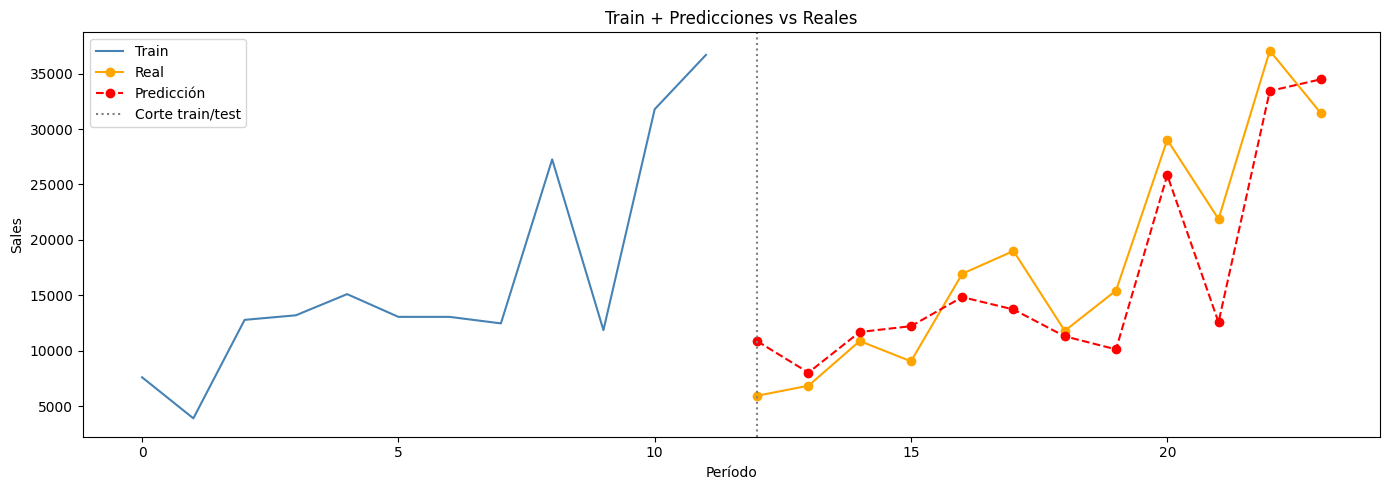

In [68]:
plt.figure(figsize=(14, 5))
plt.plot(range(len(y_train)), y_train.values, label='Train', color='steelblue')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test.values, label='Real', color='orange', marker='o')
plt.plot(range(len(y_train), len(y_train) + len(y_pred)), y_pred, label='Predicción', color='red', linestyle='--', marker='o')
plt.axvline(x=len(y_train), color='gray', linestyle=':', label='Corte train/test')
plt.title('Train + Predicciones vs Reales')
plt.xlabel('Período')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq':    1,  # necesario para que subsample tenga efecto
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }

    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=tscv,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

print('Mejores parametros:', study_lgbm.best_params)
print('Mejor MAE (cv):', study_lgbm.best_value)


Best trial: 80. Best value: 5403.82: 100%|██████████| 100/100 [00:12<00:00,  8.13it/s]

Mejores parametros: {'n_estimators': 246, 'learning_rate': 0.024917306568315686, 'max_depth': 9, 'num_leaves': 69, 'subsample': 0.9367267272303317, 'colsample_bytree': 0.7770115372666492, 'min_child_samples': 1, 'reg_alpha': 0.007255843787064287, 'reg_lambda': 0.0002988703361183564}
Mejor MAE (cv): 5403.822888681672


In [70]:
best_lgbm = LGBMRegressor(**study_lgbm.best_params)
best_lgbm.fit(X_train, y_train)

y_pred_lgbm = best_lgbm.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgbm)))
print("R²:", r2_score(y_test, y_pred_lgbm))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 71
[LightGBM] [Info] Number of data points in the train set: 12, number of used features: 14
[LightGBM] [Info] Start training from score 16575.119649
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

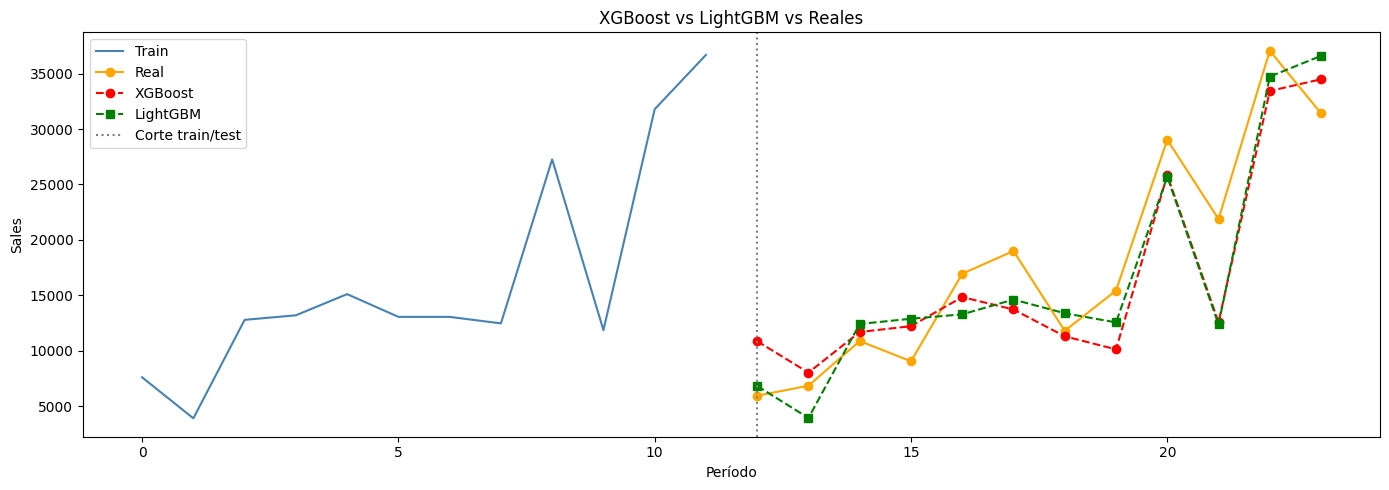

In [71]:
plt.figure(figsize=(14, 5))
plt.plot(range(len(y_train)), y_train.values, label='Train', color='steelblue')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test.values, label='Real', color='orange', marker='o')
plt.plot(range(len(y_train), len(y_train) + len(y_pred)), y_pred, label='XGBoost', color='red', linestyle='--', marker='o')
plt.plot(range(len(y_train), len(y_train) + len(y_pred_lgbm)), y_pred_lgbm, label='LightGBM', color='green', linestyle='--', marker='s')
plt.axvline(x=len(y_train), color='gray', linestyle=':', label='Corte train/test')
plt.title('XGBoost vs LightGBM vs Reales')
plt.xlabel('Período')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


In [72]:
results = pd.DataFrame({
    'Modelo': ['XGBoost', 'LightGBM'],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ],
    'R²': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_lgbm)
    ]
}).set_index('Modelo').round(2)

results


,MAE,RMSE,R²
Modelo,,,
XGBoost,3536.66,4243.97,0.81
LightGBM,3498.69,4114.28,0.82


In [73]:
def forecast_future(model, monthly_sales, n_months=12):
    history = monthly_sales[['Order Date', 'Sales']].copy()
    last_date = history['Order Date'].max()
    predictions = []
    dates = []

    for i in range(1, n_months + 1):
        next_date = last_date + pd.DateOffset(months=i)
        s = history['Sales']

        row = {
            'year': next_date.year,
            'month': next_date.month,
            'quarter': next_date.quarter,
            'lag_1': s.iloc[-1],
            'lag_2': s.iloc[-2],
            'lag_3': s.iloc[-3],
            'lag_6': s.iloc[-6],
            'lag_9': s.iloc[-9],
            'lag_12': s.iloc[-12],
            'rolling_mean_3': s.iloc[-3:].mean(),
            'rolling_std_3': s.iloc[-3:].std(),
            'rolling_mean_6': s.iloc[-6:].mean(),
            'rolling_mean_12': s.iloc[-12:].mean(),
            'yoy_growth': (s.iloc[-12] - s.iloc[-24]) / s.iloc[-24],
            'expanding_mean': s.mean(),
        }

        X_future = pd.DataFrame([row])
        X_future = X_future[X_train.columns]  # alinear columnas con el modelo
        pred = model.predict(X_future)[0]

        predictions.append(pred)
        dates.append(next_date)

        new_row = pd.DataFrame({'Order Date': [next_date], 'Sales': [pred]})
        history = pd.concat([history, new_row], ignore_index=True)

    return pd.DataFrame({'Order Date': dates, 'Forecast': predictions})


In [74]:
forecast_xgb  = forecast_future(best_model, monthly_sales, n_months=12)
forecast_lgbm = forecast_future(best_lgbm,   monthly_sales, n_months=12)


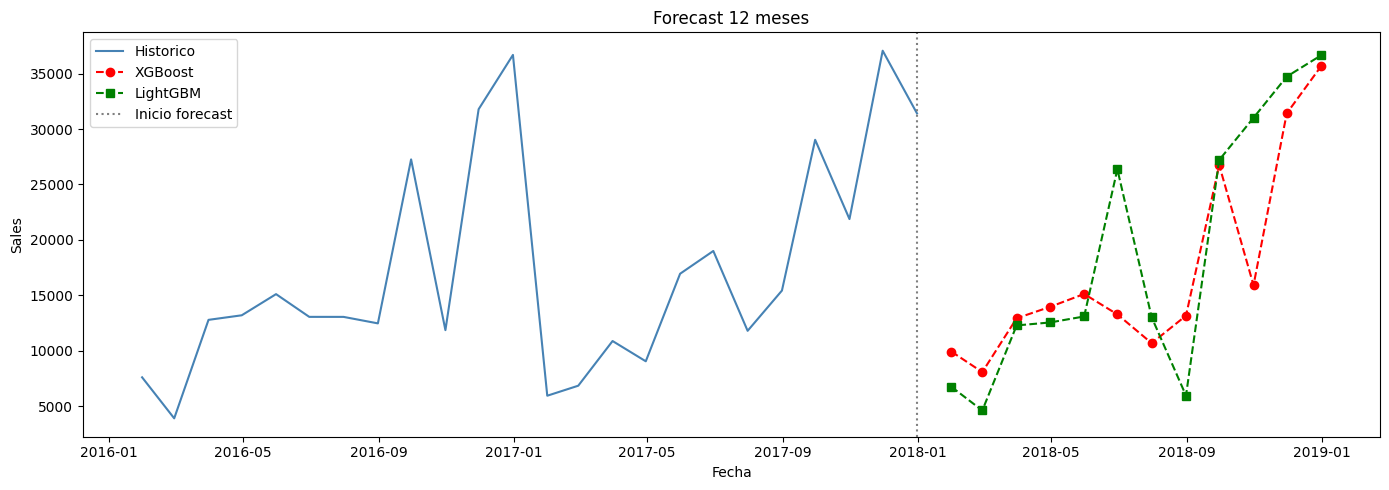

In [75]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Historico', color='steelblue')
plt.plot(forecast_xgb['Order Date'],  forecast_xgb['Forecast'],  label='XGBoost',  color='red',   linestyle='--', marker='o')
plt.plot(forecast_lgbm['Order Date'], forecast_lgbm['Forecast'], label='LightGBM', color='green', linestyle='--', marker='s')
plt.axvline(x=monthly_sales['Order Date'].max(), color='gray', linestyle=':', label='Inicio forecast')
plt.title('Forecast 12 meses')
plt.xlabel('Fecha')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


In [76]:
forecast_xgb.merge(forecast_lgbm, on='Order Date', suffixes=(' XGBoost', ' LightGBM')).round(2)


,Order Date,Forecast XGBoost,Forecast LightGBM
0,2018-01-31,9943.540039,6771.43
1,2018-02-28,8094.520020,4632.63
2,2018-03-31,12943.660156,12298.77
3,2018-04-30,13965.900391,12563.75
4,2018-05-31,15133.419922,13106.41
5,2018-06-30,13294.540039,26373.37
6,2018-07-31,10698.669922,13031.07
7,2018-08-31,13177.370117,5974.47
8,2018-09-30,26746.339844,27210.17
9,2018-10-31,15920.889648,31011.42
